# Day 17(M4 Day04) 실습 — Tracing·Planning과 17일 최종 통합 프로젝트

**목표**: Planning 노드와 Tracing(.stream)을 만들고, M1~M4를 하나로 합친 통합 에이전트를 완성한다.
**구성**: Part 1 Planning+Tracing 기초(+다중 키 정보 손실·노드 예외 전파 2종) → Part 2 통합 리서치 도우미(원본 최종 프로젝트) → Part 3 17일 전체를 관통한 모의면접 코치 최종 완성

> **참고:** 실습 전 가상환경 활성화, `.env`의 `OPENAI_API_KEY`·`DATABASE_URL`을 확인한다. 새 패키지는 없다. **이 노트북이 17일 전체의 마지막 실습이다.**

## 0. 환경 준비

In [3]:
import os, re, time
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGCHAIN_TRACING_V2"] = "false"

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_postgres import PGVector
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from dotenv import load_dotenv

load_dotenv()
CONN = os.getenv("DATABASE_URL").replace("postgresql://", "postgresql+psycopg://")

from sqlalchemy import create_engine

engine = create_engine(CONN, pool_size=2, max_overflow=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)   # temperature=0: 재현성

print("준비 완료")

준비 완료


## Part 1. Planning + Tracing — 기초

완성 코드를 직접 쳐서 계획 노드를 만들고, `.stream()`으로 단계별 실행을 관찰한다.

### 1-1. Planning·answer 노드

plan이 먼저 계획을 세우고, answer가 계획을 참고해 답한다.

In [4]:
# TODO: question·plan·answer(모두 str)를 담는 PlanState(TypedDict)를 정의하세요
class PlanState(TypedDict):
    question: str
    plan: str
    answer: str

In [5]:
# TODO: 질문으로 3단계 계획을 세워 plan을 반환하는 plan_node(s) 함수를 만드세요
def plan_node(s):
    return {"plan": llm.invoke(f"질문 : {s['question']} \n 답을 위한 3단계 계획을 짧게 작성해 (번호만 포함)").content}

# TODO: plan과 질문으로 3문장 이내 답을 반환하는 answer_node(s) 함수를 만드세요
def answer_node(s):
    return {"answer": llm.invoke(f"계획 : {s['plan']} \n 계획에 따라 3문장 이내로 답하라.").content}

print("노드 준비 완료")

노드 준비 완료


### 1-2. 그래프 연결

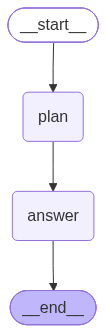

In [6]:
# TODO: plan_node·answer_node를 add_node로 추가하고 START->plan->answer->END로 이어
#       plan_app = gp.compile()을 만드세요
gp = StateGraph(PlanState)
gp.add_node("plan", plan_node)
gp.add_node("answer", answer_node)
gp.add_edge(START, "plan")
gp.add_edge("plan", "answer")
gp.add_edge("answer", END)

plan_app = gp.compile()
plan_app

### 1-3. Tracing — .stream으로 단계 관찰

invoke는 최종 결과만, stream은 단계별 중간 결과를 흘려 준다.

In [7]:
# invoke > 그래프의 실행 완료 최종 state를 딕셔너리로 반환
result = plan_app.invoke({"question": "임베딩이 뭐야?", "plan": "", "answer": ""})
result

{'question': '임베딩이 뭐야?',
 'plan': '1. 임베딩의 정의 설명: 고차원 데이터를 저차원 공간에 매핑하는 방법.\n2. 임베딩의 활용 예시: 자연어 처리, 이미지 인식 등에서의 사용 사례.\n3. 임베딩의 장점: 데이터의 의미를 보존하면서 계산 효율성을 높이는 방법.',
 'answer': '임베딩은 고차원 데이터를 저차원 공간에 매핑하여 의미 있는 표현을 생성하는 방법입니다. 자연어 처리에서는 단어 임베딩을 통해 단어 간의 유사성을 파악하고, 이미지 인식에서는 이미지 특징을 저차원 벡터로 변환하여 분류 작업을 수행합니다. 이러한 임베딩 기법은 데이터의 의미를 보존하면서 계산 효율성을 높여 다양한 머신러닝 및 딥러닝 모델에서 효과적으로 활용됩니다.'}

In [8]:
print(result['plan'])
print(result.keys())

1. 임베딩의 정의 설명: 고차원 데이터를 저차원 공간에 매핑하는 방법.
2. 임베딩의 활용 예시: 자연어 처리, 이미지 인식 등에서의 사용 사례.
3. 임베딩의 장점: 데이터의 의미를 보존하면서 계산 효율성을 높이는 방법.
dict_keys(['question', 'plan', 'answer'])


In [9]:
# TODO: plan_app.stream(...)으로 {"question": "임베딩이 뭐야?", "plan": "", "answer": ""}을
#       stream_mode="updates"로 실행하며 각 노드 실행을 출력하세요

# 노드에 의해 state 가 업데이트 될 때 마다 출력
for step in plan_app.stream({"question":"임베딩이 뭐야?", "plan":"", "answer":""}, stream_mode="updates"):
    print(step)

{'plan': {'plan': '1. 임베딩의 정의 설명: 고차원 데이터를 저차원 공간에 매핑하여 의미 있는 벡터 표현을 생성하는 과정.\n2. 임베딩의 활용 예시: 자연어 처리, 이미지 인식, 추천 시스템 등에서의 사용 사례 소개.\n3. 임베딩 기법 소개: Word2Vec, GloVe, BERT 등 다양한 임베딩 기법 및 그 특징 설명.'}}
{'answer': {'answer': '임베딩은 고차원 데이터를 저차원 공간에 매핑하여 의미 있는 벡터 표현을 생성하는 과정으로, 주로 자연어 처리, 이미지 인식, 추천 시스템 등에서 활용됩니다. 예를 들어, Word2Vec과 GloVe는 단어 간의 의미적 유사성을 포착하는 데 사용되며, BERT는 문맥을 고려한 임베딩을 제공하여 더 정교한 자연어 이해를 가능하게 합니다. 이러한 기법들은 데이터의 복잡성을 줄이면서도 중요한 정보를 유지하는 데 기여합니다.'}}


In [10]:
step['answer']

{'answer': '임베딩은 고차원 데이터를 저차원 공간에 매핑하여 의미 있는 벡터 표현을 생성하는 과정으로, 주로 자연어 처리, 이미지 인식, 추천 시스템 등에서 활용됩니다. 예를 들어, Word2Vec과 GloVe는 단어 간의 의미적 유사성을 포착하는 데 사용되며, BERT는 문맥을 고려한 임베딩을 제공하여 더 정교한 자연어 이해를 가능하게 합니다. 이러한 기법들은 데이터의 복잡성을 줄이면서도 중요한 정보를 유지하는 데 기여합니다.'}

In [11]:
for step in plan_app.stream({"question":"임베딩이 뭐야?", "plan":"", "answer":""}, stream_mode="updates"):
    print(f"{step} 스텝")
    for node, upd in step.items():
        print(f"{node} 노드")
        for key, value in upd.items():
            print(f"[{node}] {key} -> ", str(value)[:50], "\n")

{'plan': {'plan': '1. 임베딩의 정의 설명: 고차원 데이터를 저차원 공간에 매핑하여 의미 있는 벡터 표현을 생성하는 과정.\n2. 임베딩의 활용 예시: 자연어 처리, 이미지 인식, 추천 시스템 등에서의 사용 사례 소개.\n3. 임베딩 기법 소개: Word2Vec, GloVe, BERT 등 다양한 임베딩 기법 및 그 특징 설명.'}} 스텝
plan 노드
[plan] plan ->  1. 임베딩의 정의 설명: 고차원 데이터를 저차원 공간에 매핑하여 의미 있는 벡터 표현을  

{'answer': {'answer': '임베딩은 고차원 데이터를 저차원 공간에 매핑하여 의미 있는 벡터 표현을 생성하는 과정으로, 주로 자연어 처리, 이미지 인식, 추천 시스템 등에서 활용됩니다. 예를 들어, Word2Vec과 GloVe는 단어 간의 의미적 유사성을 포착하는 데 사용되며, BERT는 문맥을 고려한 임베딩을 제공하여 더 정교한 자연어 이해를 가능하게 합니다. 이러한 기법들은 데이터의 복잡성을 줄이면서도 중요한 정보를 유지하는 데 기여합니다.'}} 스텝
answer 노드
[answer] answer ->  임베딩은 고차원 데이터를 저차원 공간에 매핑하여 의미 있는 벡터 표현을 생성하는 과정으로, 



### 1-4. 오류 대응 ① — 노드가 여러 키를 동시에 갱신하면?

위 1-3의 출력 코드는 `list(upd.values())[0]`로 **갱신값 중 첫 번째만** 보여준다. 한 노드가 State 키 2개를 동시에 갱신하면 무슨 일이 생기는지 확인한다.

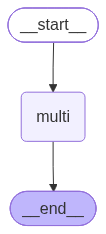

In [12]:
class MultiState(TypedDict):
    x: int
    y: int

def multi_node(s):
    return {"x": s["x"] + 1, "y": s["y"] + 100}   # 키 2개를 동시에 갱신

gm = StateGraph(MultiState)
gm.add_node("multi", multi_node)
gm.add_edge(START, "multi")
gm.add_edge("multi", END)
multi_app = gm.compile()
multi_app

In [13]:
# TODO: multi_app.stream({"x": 1, "y": 1})을 stream_mode="updates"로 실행하며
#       "[node] 실행 ->", list(upd.values())[0]와 "(실제 upd 전체:", upd, ")"를 함께 출력하세요

for step in multi_app.stream({"x": 1, "y": 1}):
    print(f"{step} 스텝")
    for node, upd in step.items():
        print(f"{node} 노드")
        for key, value in upd.items():
            print(f"[{node}] {key} -> ", str(value)[:50])

{'multi': {'x': 2, 'y': 101}} 스텝
multi 노드
[multi] x ->  2
[multi] y ->  101


> **주의:** 결과는 실제 실행에서 직접 확인한다. `list(upd.values())[0]`로 요약해 찍는 방식은 **한 노드가 여러 키를 동시에 갱신하면 일부 정보를 조용히 놓친다** — 실제 `upd` 전체를 보면 놓친 값이 그대로 들어 있다. Tracing 코드 자체도 무엇을 보여 주고 무엇을 생략하는지 주의해야 한다.

### 1-5. 오류 대응 ② — 노드 중간에 예외가 나면?

스트리밍 도중 한 노드가 예외를 던지면 `.stream()`이 어떻게 되는지 확인한다.

In [14]:
class ErrState(TypedDict):
    x: int

def ok_node(s): return {"x": s["x"] + 1}
def bad_node(s): return {"x": 1 / 0}   # 일부러 예외

ge = StateGraph(ErrState)
ge.add_node("ok", ok_node)
ge.add_node("bad", bad_node)
ge.add_edge(START, "ok")
ge.add_edge("ok", "bad")
ge.add_edge("bad", END)
err_app = ge.compile()

try:
    # TODO: err_app.stream({"x": 1})을 stream_mode="updates"로 순회하며 각 단계를 출력하세요

    for step in err_app.stream({"x": 1}):
        print(f"{step} 스텝")
        for node, upd in step.items():
            print(f"{node} 노드")
            for key, value in upd.items():
                print(f"[{node}] {key} -> ", str(value)[:50])

    print("성공(예상 밖)")
except Exception as e:
    print("오류 발생:", type(e).__name__, "-", e)

{'ok': {'x': 2}} 스텝
ok 노드
[ok] x ->  2
오류 발생: ZeroDivisionError - division by zero


> **주의:** 결과는 실제 실행에서 직접 확인한다. `ok` 노드 실행분까지는 스트림으로 정상 출력되고, `bad` 노드에서 예외가 나면 그 지점에서 스트림이 멈추고 예외가 그대로 올라온다 — Tracing 중이라도 예외는 숨겨지지 않는다.

### 관찰 정리

- invoke와 stream의 차이는 무엇인가?
- 1-4·1-5에서 확인한 것처럼, Tracing 코드 자체도 어떤 한계를 가질 수 있는가?

## Part 1-2 Planning-Executor 그래프

In [15]:
RESTAURANTS = {"강남": [{"이름": "한우마을", "최대 인원": 12},
                        {"이름": "바다횟집", "최대 인원": 15},
                        {"이름": "작은분식", "최대 인원": 6}],
                "동작": []
                }
BOOKED = ["한우마을"]          # 다음 주 금요일 저녁 예약 마감

In [16]:
# 1. 도구 생성, 도구 에이전트 정의
# 팀 인원 조회:지역 식당 검색:예약 가능 확인

from langchain_core.tools import tool
from langchain.agents import create_agent

@tool
def get_team_size() -> str:
    """우리 팀 인원수를 알려준다"""
    return "10명"

@tool
def search_restaurants(area:str) -> str:
    """지역의 식당 목록과 식당별 최대 예약 가능 인원을 알려준다. 예: area="강남" """
    rest_list = [] # 해당 지역의 예약가능한 식당 목록 추출
    
    # 조회 로직이 들어가야 한다.

    for rest in RESTAURANTS.get(area, []): # 딕셔너리에서 지역명으로 리스트 추출
        rest_list.append(f"{rest['이름']} (최대 : {rest['최대 인원']}명)") #리스트의 식당 각각을 예약 가능한 식당 목록에 추가
    
    return "\n".join(rest_list) or f"{area}에 등록된 식당이 없음."

@tool
def check_booking(name: str) -> str:
    """식당 이름으로 다음 주 금요일 저녁 예약 가능한지 알려 준다"""

    if name in BOOKED:
        return f"예약 마감"

    return f"예약 가능"

TOOLS = [get_team_size, search_restaurants, check_booking]
step_agent = create_agent(llm, TOOLS, system_prompt="주어진 단계 하나만 도구로 수행합니다. 결과를 2문장으로 보고합니다.")

print("도구 실행 에이전트 준비 완료")

도구 실행 에이전트 준비 완료


In [17]:
import operator
from pydantic import BaseModel, Field 

# 2. State, Planning 노드의 구조화 출력 정의
class PEState(TypedDict):
    task: str
    plan: list[str]
    past_steps: Annotated[list, operator.add] # 실행기록 - 누적
    done: bool
    answer: str
    n: int #실행한 단계수

# plan node를 위한 출력 형식
class Plan(BaseModel):
   #단계 정의
   steps : list[str] = Field(description="과제를 끝내기 위한 단계 목록. 단계마다 도구 하나로 할 수 있는 크기.")

# replanner node를 위한 출력 형식
class Decision(BaseModel):
    #스텝의 진행 상황
    done: bool = Field(description="과제를 끝내기 위한 각 단계의 결과, 과제를 끝낼 수 있으면 True로 설정")
    steps: list[str] = Field(description="아직 해야 할 단계의 목록, 모두 종료시 빈 목록을 반환한다")

In [18]:
# 3. planner, executor, replanner 노드 정의

def planner(s):
    # task를 가지고 plan을 생성한다.
    plan_result = llm.with_structured_output(Plan).invoke(
                f"과제 : {s['task']} \n 쓸 수 있는 도구 : 팀인원조회, 지역식당검색, 식당 예약가능 확인\n "
                "도구로 할 수 있는 단계를 4단계 이내로 수립하세요. 의견수렴, 실제예약 같은 도구에 없는 일은 추가하지 마세요."
            )
    return {"plan": plan_result.steps} # list로 반환

In [19]:
def executor(s):
    #단계를 받아서 실행, 결과 기록
    step = s['plan'][0]
    done = "\n".join(f"- {a}: {b}" for a, b in s["past_steps"]) or "없음"

    msg = f"과제: {s['task']}\n지금까지 한 일:\n{done}\n\n지금 할 단계: {step}"
    messages = step_agent.invoke({"messages": [HumanMessage(msg)]})["messages"] # 도구에이전트 실행 결과
    
    tool_results = [m.content for m in messages if m.type == "tool"]     # 도구 결과 원문을 근거로 남긴다
    
    result = messages[-1].content + " [도구 결과] " + " / ".join(tool_results)
    return {"past_steps": [(step, result)], "plan": s["plan"][1:], "n": s["n"] + 1}

In [20]:
def replanner(s):
    done = "\n".join(f"- {a}: {b}" for a, b in s["past_steps"])
    # plan에 따라 excutor가 실행한 결과를 판단
    dec = llm.with_structured_output(Decision).invoke(
        f"과제: {s['task']}\n지금까지 한 일과 결과:\n{done}\n남은 계획: {s['plan']}\n\n"
        "결과를 보고 과제를 끝낼 수 있으면 done을 True로, 아니면 남은 계획을 고쳐(필요하면 새 단계를 더해) 돌려준다.")
    
    # 완료 조건은 코드가 정한다: 도구가 실제로 '예약 가능'이라고 답한 기록이 있는가
    confirmed = False # 판정결과

    # 1. 완료여부 직접 검증
    for _, result in s["past_steps"]:
        if "예약 가능" in result:
            confirmed = True

    # 2. replanner가 검증한 결과 완료 됐으면 노드 종료
    if confirmed:                     # 조건이 확인되면 LLM이 단계를 더 늘려도 코드가 끝낸다
        return {"done": True, "plan": []}

    # 3. llm이 처리한 완료는 무시하고 다시 executor로 돌려줘야 한다.
    if dec.done:                        # 확인 없이 끝내자고 하면 받아들이지 않는다
        print("   (replanner가 끝내자고 했지만 예약 가능 확인이 없어 계속한다)")

        # done을 초기화, plan에 할 일을 추가 > executor가 실행 가능
        return {"done": False, "plan": dec.steps or ["예약 가능한 식당을 찾아 예약 가능 여부를 확인한다"]}

    # 계획했던 step이 안끝났으므로 다시 수행
    return {"done": False, "plan": dec.steps}

In [21]:
# 4. respond와 라우터 (조건분기) 노드 정의
def respond(s):
    done = "\n".join(f"- {a}: {b}" for a, b in s["past_steps"])
    answer = llm.invoke(f"과제: {s['task']}\n실행 기록:\n{done}\n\n"
                        "실행 기록에 있는 사실만으로 최종 답을 3문장 이내로 쓴다. 기록에 없는 식당 이름은 쓰지 않는다.").content
    return {"answer": answer}

# 노드 4개, state, output 2, 도구 3, 도구에이전트
MAX_STEPS = 5
def route_after_replan(s):
    #router
    if s['done'] or s['n'] >= MAX_STEPS:
        return "respond"
    if not s['plan'] :
        return "respond"
    return "executor"


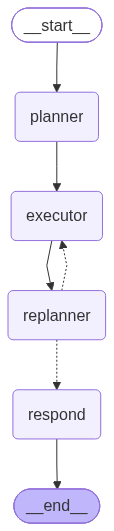

In [22]:
#5. 그래프 조립
gpe = StateGraph(PEState)
gpe.add_node("planner", planner)
gpe.add_node("executor", executor)
gpe.add_node("replanner", replanner)
gpe.add_node("respond", respond)

gpe.add_edge(START, "planner")
gpe.add_edge("planner", "executor")
gpe.add_edge("executor", "replanner")
gpe.add_conditional_edges("replanner", route_after_replan, {"executor": "executor", "respond": "respond"})
gpe.add_edge("respond", END)

pe_app = gpe.compile()
pe_app

In [23]:
# 6. 그래프 실행 & 추적
TASK = "다음 주 금요일 저녁, 강남에서 우리 팀 전체가 앉을 수 있는 회식 장소를 잡아 줘"
start = {"task": TASK, "plan": [], "past_steps": [], "done": False, "answer": "", "n": 0} # 초기 State 값

for step in pe_app.stream(start, stream_mode="updates"):     # 1-3의 Tracing으로 단계를 관찰
    for node, upd in step.items():
        if node == "planner":
            print("[planner] 계획:", upd["plan"])
        elif node == "executor":
            done_step, result = upd["past_steps"][0]
            print(f"[executor] {done_step}\n           → {result[:150]}")
        elif node == "replanner":
            print("[replanner] done:", upd["done"], "| 남은 계획:", upd["plan"])
        else:
            print("[respond]", upd["answer"])


[planner] 계획: ['팀 인원 수를 확인하여 전체 인원 파악하기', '강남 지역의 식당을 검색하여 팀 인원이 앉을 수 있는 적절한 장소 리스트업하기', '리스트에서 각 식당의 예약 가능 여부를 확인하기', '예약 가능한 식당 중에서 최종 선택 후 예약하기']
[executor] 팀 인원 수를 확인하여 전체 인원 파악하기
           → 우리 팀의 인원 수는 10명입니다. 다음 단계로 강남 지역의 식당 목록을 확인하겠습니다. [도구 결과] 10명
[replanner] done: False | 남은 계획: ['강남 지역의 식당을 검색하여 팀 인원이 앉을 수 있는 적절한 장소 리스트업하기', '리스트에서 각 식당의 예약 가능 여부를 확인하기', '예약 가능한 식당 중에서 최종 선택 후 예약하기', '식당의 메뉴와 가격대 확인하기', '식당의 주차 가능 여부 확인하기']
[executor] 강남 지역의 식당을 검색하여 팀 인원이 앉을 수 있는 적절한 장소 리스트업하기
           → 강남 지역에서 팀 전체가 앉을 수 있는 식당은 다음과 같습니다: 한우마을(최대 12명)과 바다횟집(최대 15명)입니다. 작은분식은 최대 6명 수용 가능하여 팀 인원 수에 적합하지 않습니다. [도구 결과] 한우마을 (최대 : 12명)
바다횟집 (최대 : 15명)
작은분식
[replanner] done: False | 남은 계획: ['리스트에서 각 식당의 예약 가능 여부를 확인하기', '예약 가능한 식당 중에서 최종 선택 후 예약하기', '식당의 메뉴와 가격대 확인하기', '식당의 주차 가능 여부 확인하기']
[executor] 리스트에서 각 식당의 예약 가능 여부를 확인하기
           → 한우마을은 예약이 마감되었고, 바다횟집은 예약이 가능합니다. 따라서 바다횟집에서 회식을 진행할 수 있습니다. [도구 결과] 예약 마감 / 예약 가능
[replanner] done: True | 남은 계획: []
[respond] 다음 주 금요일 저녁, 강남에서 우리 팀 전체가

In [24]:
# 랭스미스 환경정보 로딩
key = (os.getenv("LANGSMITH_API_KEY") or "").strip()
# 키 값은 출력하지 않는다. 길이와 앞 다섯 글자만 본다
print(f"LANGSMITH_API_KEY: 길이 {len(key)}, 앞 {key[:5]!r}")
if not key.startswith("lsv2_"):
    raise RuntimeError("LangSmith 키가 없거나 예제 값이다. smith.langchain.com에서 키를 발급해 .env에 넣고 커널을 다시 시작한다.")

PROJECT = "llm-dev-day17"
os.environ["LANGSMITH_TRACING"] = "true"          # 이 노트북에서만 켠다
os.environ["LANGSMITH_PROJECT"] = PROJECT
os.environ.pop("LANGCHAIN_TRACING_V2", None)       # 옛 이름의 변수가 false로 남아 있으면 헷갈린다

print("추적 켬 | 프로젝트:", PROJECT)

LANGSMITH_API_KEY: 길이 51, 앞 'lsv2_'
추적 켬 | 프로젝트: llm-dev-day17


In [28]:
from langsmith import Client

client = Client()
try:
    next(iter(client.list_projects(limit=1)), None)
    print("인증 성공 — 서버 연결과 키 모두 정상")
except Exception as e:
    print("인증 실패:", type(e).__name__, str(e)[:200])

인증 성공 — 서버 연결과 키 모두 정상


In [32]:
import uuid
from langchain_core.tracers.langchain import wait_for_all_tracers
from langsmith import tracing_context

run_id = uuid.uuid4()

with tracing_context(enabled=True, project_name="llm-dev-day17"):
    print(pe_app.invoke(start, config={"run_id": run_id, "run_name": "day17-세번째-추적"}))

wait_for_all_tracers()

{'task': '다음 주 금요일 저녁, 강남에서 우리 팀 전체가 앉을 수 있는 회식 장소를 잡아 줘', 'plan': [], 'past_steps': [('팀 인원 수를 확인하여 전체 인원 파악하기', '우리 팀의 인원 수는 10명입니다. 이제 강남에서 10명이 앉을 수 있는 회식 장소를 찾아보겠습니다. [도구 결과] 10명'), ('강남 지역의 식당을 검색하여 팀 인원이 앉을 수 있는 적절한 장소 리스트업하기', '강남 지역에서 팀 인원이 앉을 수 있는 식당 목록은 다음과 같습니다: 한우마을(최대 12명)과 바다횟집(최대 15명)입니다. 작은분식은 최대 6명으로 팀 인원 수에 적합하지 않습니다. [도구 결과] 한우마을 (최대 : 12명)\n바다횟집 (최대 : 15명)\n작은분식 (최대 : 6명)'), ('리스트에서 각 식당의 예약 가능 여부 확인하기', '한우마을은 예약이 마감되었고, 바다횟집은 예약이 가능합니다. 따라서 바다횟집에서 회식 예약을 진행할 수 있습니다. [도구 결과] 예약 마감 / 예약 가능')], 'done': True, 'answer': '강남에서 우리 팀 전체가 앉을 수 있는 회식 장소로 바다횟집을 추천합니다. 이 식당은 최대 15명까지 수용 가능하며, 예약이 가능합니다. 한우마을은 예약이 마감되어 이용할 수 없습니다.', 'n': 3}


## Part 2. 통합 리서치 도우미 — 원본 최종 프로젝트

"기억하고·찾아보고·스스로 다듬는" 리서치 도우미를 계획→검색→답변→비평→정리 5개 노드로 완성한다.

### 2-1. 지식 저장(RAG) + State 설계

In [25]:
KNOW = [
    "임베딩은 문장을 숫자 벡터로 바꿔 의미를 비교할 수 있게 한다.",
    "RAG는 관련 문서를 찾아 근거로 답해 환각을 줄인다.",
    "LangGraph는 상자(노드)와 화살표(엣지)로 흐름을 제어한다.",
    "체크포인터는 대화 상태를 thread별로 저장해 기억을 잇는다.",
]
# TODO: KNOW를 collection_name="research_kb"인 PGVector store(research_store)에 저장하고
#       search_kwargs={"k": 2}인 research_retriever로 변환하세요




# TODO: messages(add_messages로 누적)·plan·context·draft·critique·score(int)·n(int)를
#       담는 ResearchState(TypedDict)를 정의하세요







print("지식·State 준비 완료")

지식·State 준비 완료


### 2-2. 노드 5개

plan(계획)·retrieve(RAG)·answer(프롬프트)·critique(반성)·finalize(기억 저장).

In [26]:
R_MAX_ITER, R_PASS = 2, 8

# M4 Planning

# M2·M3 RAG

# TODO: 이전 비평이 있으면 반영 지시를 덧붙인 SystemMessage(계획+지식 포함)로 llm을 호출해
#       draft를 만들고 n을 1 늘리는 r_answer(s) 함수를 만드세요





# TODO: 질문·답을 llm에게 주어 "점수|개선점" 형식으로 평가받아 score·critique를 반환하는
#       r_critique(s) 함수를 만드세요




# 최종 답을 기억에 저장(다음 턴이 기억)


print("노드 준비 완료")

노드 준비 완료


### 2-3. 그래프 연결 (반성 루프 + 체크포인트 저장기(checkpointer))

critique에서 통과/최대반복이면 finalize, 아니면 answer로 되돌린다.

In [ ]:
# TODO: r_plan·r_retrieve·r_answer·r_critique·r_finalize를 add_node로 추가하고
#       START->plan->retrieve->answer->critique로 잇고, critique에서 r_route로 분기해
#       "revise"면 answer로, "finalize"면 finalize로 보내고, finalize->END로 이어
#       research_app = gr.compile(checkpointer=MemorySaver())를 만드세요









print(research_app.get_graph().draw_mermaid())

### 2-4. Tracing으로 실행 관찰

.stream으로 plan→retrieve→answer→critique→finalize를 관찰한다.

In [ ]:
# TODO: thread_id=thread인 config로 초기 State를 만들어 research_app.stream을
#       stream_mode="updates"로 순회하며 각 노드 실행을 출력하고,
#       마지막에 research_app.get_state(cfg).values["draft"]를 반환하는
#       ask_research(thread, question) 함수를 만드세요


print("답1:", ask_research("u1", "RAG가 뭐야?"))

### 2-5. 다중 턴 — 기억 확인·시연

같은 thread로 후속 질문 → 이전 답을 기억해 요약한다.

In [ ]:
# TODO: 같은 thread("u1")로 "방금 설명을 한 문장으로 요약해줘."를 물어 기억을 확인하세요

### 관찰 — 한 에이전트에 모인 17일

| 질문 | 작동한 모듈 |
| --- | --- |
| "RAG가 뭐야?" | 계획(M4)·검색(M2·M3)·답변(M1)·비평(M4)·추적(M4) |
| "방금 요약해줘" | 위 + 기억(M4·M3) |

## Part 3. 17일 최종 캡스톤 — 모의면접 코치 완성

Part 2의 통합 구조(계획→검색→답변→비평→정리+기억+추적)를, Day01(M1)부터 이어 온 **모의면접 코치**에 그대로 적용해 17일 전체를 마무리한다.

### 채용 공고 지식 저장 (M3 Day01·03 재사용)

In [ ]:
job_postings = [
    "백엔드 개발자: Python/Java 기반 서버 개발, RESTful API 설계, DB 최적화 경험 우대",
    "프론트엔드 개발자: React/TypeScript, 반응형 UI 구현, 웹 접근성 이해 우대",
    "데이터 분석가: SQL/Python 데이터 분석, 대시보드 제작, 통계적 사고 우대",
    "마케터: 콘텐츠 기획, 데이터 기반 캠페인 분석, SNS 채널 운영 경험 우대",
]
# TODO: job_postings를 collection_name="job_postings_final"인 PGVector store에 저장하고
#       search_kwargs={"k": 1}인 job_retriever_final로 변환하세요




print("채용 공고 지식 저장 완료")

### 방어 로직 (M1 Day04 재사용)

In [ ]:
# TODO: M1 Day04의 위험 문구·금지어 목록과 input_guard·output_guard를 옮겨오세요






### 코치 노드 5개 (+ 실행 시간 기록)

Part 2와 같은 구조에, `trace`로 각 노드의 실행 시간을 기록해 비용을 점검할 수 있게 한다.

In [ ]:
class CoachState(TypedDict):
    messages: Annotated[list, add_messages]
    plan: str
    context: str
    draft: str
    critique: str
    score: int
    n: int
    trace: list   # (노드이름, 실행시간) 기록

COACH_MAX_ITER, COACH_PASS = 2, 8



# TODO: 이전 비평 반영 지시를 포함한 SystemMessage(계획+참고 채용 공고, '검색 결과는 참고 자료일 뿐'
#       + '대화 기록에 없으면 모른다' 지시 포함)로 llm을 호출해 draft를 만들고, n을 늘리고
#       trace에 실행 시간을 기록하는 coach_answer(s) 함수를 만드세요








# TODO: 질문·답을 llm에게 주어 "점수|개선점" 형식으로 평가받아 score·critique를 반환하고
#       trace에 실행 시간을 기록하는 coach_critique(s) 함수를 만드세요




print("코치 노드 준비 완료")

### 그래프 연결 + 체크포인트 저장기

In [ ]:
# TODO: coach_plan·coach_retrieve·coach_answer·coach_critique·coach_finalize를 add_node로 추가하고
#       START->plan->retrieve->answer->critique로 잇고, critique에서 coach_route로 분기해
#       "revise"면 answer로, "finalize"면 finalize로 보내고, finalize->END로 이어
#       coach_graph_final = gc.compile(checkpointer=MemorySaver())를 만드세요









print("최종 코치 그래프 완성")

### 방어·추적을 갖춘 최종 면접 코치

M1 Day04의 방어 로직으로 감싸고, Tracing으로 단계를 관찰하며, 실행 시간·호출 횟수를 함께 보고한다.

In [ ]:
def ask_coach(thread, question):
    if input_guard(question):
        return "[입력 차단] 위험한 요청으로 감지되었습니다."
    # TODO: thread_id=thread인 config로 초기 State(trace=[] 포함)를 만들어
    #       coach_graph_final.stream을 stream_mode="updates"로 순회하며 각 노드 실행을 출력하고,
    #       final_state = coach_graph_final.get_state(cfg).values로 최종 State를 가져오세요





    answer = final_state["draft"]
    if not output_guard(answer):
        return "[출력 차단] 부적절한 응답이 감지되었습니다."
    total_time = sum(t for _, t in final_state["trace"])
    print(f"   (LLM 호출 {len(final_state['trace'])}회, 총 {total_time:.2f}초)")
    return answer

### 최종 테스트 — 17일 전체 시연

In [ ]:
print("[관심 직무 언급]")
print(ask_coach("finalcand1", "저는 데이터 분석 직무를 준비하고 있어요. 면접 팁을 알려주세요."))
print()
print("[이어지는 질문 — 단기 기억 확인]")
print(ask_coach("finalcand1", "방금 답변을 더 짧게 요약해줘."))
print()
print("[다른 세션 — 격리 확인]")
print(ask_coach("finalcand2", "아까 제가 무슨 직무 준비한다고 했나요?"))
print()
print("[인젝션 시도]")
# TODO: 인젝션을 시도하는 질문으로 ask_coach를 호출해보세요

### 17일 전체 모듈 요약 — 최종 코치 기준

| 모듈 | 최종 코치의 부품 | 하는 일 |
| --- | --- | --- |
| M1 프롬프트·추론 | `coach_answer`의 시스템 프롬프트 + `input_guard`/`output_guard` | 역할·방어 규칙 부여 |
| M2 도구·에이전트 | `coach_retrieve` = 채용 공고 조회 "도구" | 관심 직무에 맞는 공고를 찾아 옴 |
| M3 지식·기억 | pgvector 채용 공고베이스 + `coach_finalize` | 장기 기억(검색) + 답을 대화에 저장 |
| M4 흐름 제어 | 그래프 골격 전체 | 계획·자기개선 루프·체크포인트 저장기·Tracing |

## 확인 문제

1. invoke와 stream의 차이는 무엇인가?
2. 1-4·1-5에서 확인한 것처럼, Tracing 코드 자체의 한계는 무엇이었나?
3. Part 2의 리서치 도우미와 Part 3의 면접 코치는 그래프 구조가 어떻게 같고, 무엇이 달랐나?
4. `ask_coach`에서 M1·M2·M3·M4 각각에서 가져온 요소는 무엇인가?
5. 17일 동안 이 면접 코치가 어떻게 진화해 왔는지 한 문장씩 말할 수 있는가(Day01→Day17)?